# One-to-One Classification: Cross-Combination Result Comparison

Compares model performance across every one-to-one label-pair classification trained via
`03_main_training.py --n_splits 5` on `config.LAB_1TO1_EXP_FOLDER` (`LAB_OneToOne`) --
20 combinations total: 2 strategies (`1_area`, `2_range`) x C(5,2)=10 label pairs each
(`Pf`/`Pk`/`Pm`/`Po`/`Pv`), one subfolder per combo (see `01b_lab_curve_preprocessing.py`'s
`--one_to_one` mode).

Three questions this notebook answers:
1. **Consistency across one-to-one classifications** -- for each model, how stable is its
   accuracy across all 10 (or 20) label-pair combos, not just its average?
2. **Which model is significantly better (and consistent)** -- a real significance test
   (Friedman + pairwise Wilcoxon, Holm-corrected), reusing `08_statistical_comparison.py`'s
   existing statistical engine rather than re-implementing it.
3. **`1_area` vs `2_range` consistency for the same target pairs** -- both strategies
   classify the exact same 10 label pairs; do they agree on which pairs/models work well?

Each combo's `classification_performances_10fold.joblib` has REAL 5-fold CV (unlike a
single LOFO fold), so `accuracy_std` here is genuine fold-to-fold variability, not always 0.

In [62]:
import os

try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(notebook_path))
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
%matplotlib inline

Current Working Directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
import re
import importlib.util
from itertools import combinations
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patheffects
%matplotlib inline
import config

def _load_digit_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

prep01b = _load_digit_module("prep01b", "01b_lab_curve_preprocessing.py")
stat08 = _load_digit_module("stat08", "08_statistical_comparison.py")

## 1. Configuration

Combos discovered the same way `01b_lab_curve_preprocessing.py --one_to_one` itself does
(`discover_one_to_one_combos`), so this notebook always matches whatever combinations
actually exist on disk -- no hardcoded label list to fall out of sync.

In [64]:
LAB_1TO1_FOLDER = Path(config.LAB_1TO1_EXP_FOLDER)
STRATEGIES = sorted(prep01b.FILE_MAPPING_ONE_TO_ONE.keys())

COMBOS = prep01b.discover_one_to_one_combos(str(LAB_1TO1_FOLDER))
print(f"Found {len(COMBOS)} combos across {len(STRATEGIES)} strategies:")
for strategy, label1, label2, combo_name in COMBOS:
    print(f"  {combo_name}")

# Models actually trained for this dataset: LAB curves have no spatial metadata, so
# cnn_gru_dual_cosine_recon/cnn_gru_dual_attn_recon (model_utils.evaluate_outlier_filters)
# are skipped automatically -- everything else 03_main_training.py's default `models`
# list trains is present.
MODELS = ["knn", "cnn", "gru", "transformer", "cnn_lf", "gru_lf", "trans_lf", "cnn_gru_dual", "cnn_trans_dual", "cnn_gru_gate", "cnn_gru_hadamard", "cnn_gru_crossattn", "cnn_gru_film", "cnn_trans_gate", "cnn_trans_hadamard", "cnn_trans_crossattn", "cnn_trans_film"]
MODEL_LABEL_MAP = config.MODEL_PRINT_MAP

MODEL_FIXED_COLORS = {
    "cnn": config.MODEL_COLORS["CNN"],
    "gru": config.MODEL_COLORS["GRU"],
    "transformer": config.MODEL_COLORS["Transformer"],
}
MODEL_COLOR_MAP = config.get_palette(MODELS, MODEL_FIXED_COLORS)

STRATEGY_COLOR_MAP = config.get_palette(STRATEGIES)
STRATEGY_LABEL_MAP = {"1_area": "Area Strategy", "2_range": "Range Strategy"}

N_SPLITS = 5

Found 20 combos across 2 strategies:
  1_area__Pf_vs_Pk
  1_area__Pf_vs_Pm
  1_area__Pf_vs_Po
  1_area__Pf_vs_Pv
  1_area__Pk_vs_Pm
  1_area__Pk_vs_Po
  1_area__Pk_vs_Pv
  1_area__Pm_vs_Po
  1_area__Pm_vs_Pv
  1_area__Po_vs_Pv
  2_range__Pf_vs_Pk
  2_range__Pf_vs_Pm
  2_range__Pf_vs_Po
  2_range__Pf_vs_Pv
  2_range__Pk_vs_Pm
  2_range__Pk_vs_Po
  2_range__Pk_vs_Pv
  2_range__Pm_vs_Po
  2_range__Pm_vs_Pv
  2_range__Po_vs_Pv


## 2. Load results into a tidy long-format DataFrame

One row per (combo, model) -- `accuracy_mean`/`accuracy_std` are computed across the 5
real CV folds in each combo's `classification_performances_10fold.joblib`.

In [65]:
def per_fold_accuracies(res_entry, model_key):
    pred_key, _, _ = config.MODEL_KEY_MAP[model_key]
    if pred_key not in res_entry or not res_entry[pred_key]:
        return None
    y_trues, y_preds = res_entry["y_trues_"], res_entry[pred_key]
    return [float((np.asarray(yp) == np.asarray(yt)).mean()) for yt, yp in zip(y_trues, y_preds)]


def load_one_to_one_results():
    rows = []
    for strategy, label1, label2, combo_name in COMBOS:
        results_path = LAB_1TO1_FOLDER / combo_name / config.TRAINING_10FOLD_RESULT_PATH
        if not results_path.exists():
            print(f"[WARN] no 10-fold results for {combo_name}")
            continue
        all_results = joblib.load(results_path)
        dataset_name = next(iter(all_results))  # only ever "Ori Curves" for LAB data
        res_entry = all_results[dataset_name].get("Native", {}).get(None)
        if res_entry is None:
            print(f"[WARN] no Native/baseline results for {combo_name}")
            continue
        for model in MODELS:
            accs = per_fold_accuracies(res_entry, model)
            if accs is None:
                continue
            rows.append({
                "combo": combo_name, "strategy": strategy, "pair": f"{label1}_vs_{label2}",
                "model": model, "accuracy_mean": float(np.mean(accs)) * 100,
                "accuracy_std": float(np.std(accs)) * 100, "n_folds": len(accs),
            })
    return pd.DataFrame(rows)


results_df = load_one_to_one_results()
PAIRS = sorted(results_df["pair"].unique())
print(f"\nLoaded {len(results_df)} rows. Pairs: {PAIRS}")
results_df.head()


Loaded 340 rows. Pairs: ['Pf_vs_Pk', 'Pf_vs_Pm', 'Pf_vs_Po', 'Pf_vs_Pv', 'Pk_vs_Pm', 'Pk_vs_Po', 'Pk_vs_Pv', 'Pm_vs_Po', 'Pm_vs_Pv', 'Po_vs_Pv']


,combo,strategy,pair,model,accuracy_mean,accuracy_std,n_folds
0,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,knn,94.695431,0.668626,5
1,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,cnn,99.898477,0.050761,5
2,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,gru,99.974619,0.050761,5
3,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,transformer,99.873096,0.080261,5
4,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,cnn_lf,99.949239,0.062170,5


## 3. Data completeness check

Every combo should have all 9 models; this flags anything missing (e.g. a combo whose
`03` run hasn't finished yet).

In [66]:
all_combo_names = [c[3] for c in COMBOS]
loaded_combos = set(results_df["combo"].unique())
fully_missing = [c for c in all_combo_names if c not in loaded_combos]
if fully_missing:
    print(f"{len(fully_missing)} of {len(all_combo_names)} combos have no results file at all yet:")
    for c in fully_missing:
        print(f"  {c}")

coverage = results_df.pivot_table(index="combo", columns="model", values="accuracy_mean", aggfunc="count")
coverage = coverage.reindex(columns=MODELS).fillna(0).astype(int)
partial = coverage[(coverage == 0).any(axis=1)]
if partial.empty:
    print(f"All {len(loaded_combos)} loaded combos have all {len(MODELS)} models present.")
else:
    print("Loaded combos with missing models (0 = missing):")
    display(partial)


All 20 loaded combos have all 17 models present.


## 4. Goal 1: model consistency across one-to-one classifications

For each model: mean accuracy across all combos (bar) and the spread across combos
(error bar + boxplot) -- a model that's high on average but wildly inconsistent across
label pairs is a different finding than one that's reliably mid-range everywhere.

In [67]:
_TEXT_OUTLINE = [patheffects.withStroke(linewidth=2.5, foreground="white")]

def plot_model_consistency(df, strategy=None, title_suffix=""):
    sub = df if strategy is None else df[df.strategy == strategy]
    n_combos = sub["combo"].nunique()
    agg = sub.groupby("model")["accuracy_mean"].agg(["mean", "std", "count"]).reindex(MODELS)

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = [MODEL_COLOR_MAP[m] for m in agg.index]
    ax.bar(range(len(agg)), agg["mean"].fillna(0), yerr=agg["std"].fillna(0), capsize=4,
           color=colors, edgecolor="black", zorder=3)
    for i, (m, s, c) in enumerate(zip(agg["mean"], agg["std"], agg["count"])):
        if not np.isnan(m):
            ax.text(i, m - 0.5, f"{m:.1f}±{s:.1f}%\n(n={c})", ha="center", va="top",
                     fontsize=8, fontweight="bold", path_effects=_TEXT_OUTLINE)

    valid = agg["mean"].dropna()
    ymin = max(0, (valid.min() // 10) * 10 - 10) if not valid.empty else 0
    ax.set_ylim(ymin, 100)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels([MODEL_LABEL_MAP.get(m, m) for m in agg.index], rotation=30, ha="right", fontweight="bold")
    ax.set_ylabel("Mean Accuracy (%) across combos\n(error bar = combo-to-combo std)", fontsize=11, fontweight="bold")
    ax.set_title(f"Model Consistency Across One-to-One Combos (n={n_combos} combos){title_suffix}", fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    fig.tight_layout()
    plt.show()


def plot_model_boxplot(df, strategy=None, title_suffix=""):
    sub = df if strategy is None else df[df.strategy == strategy]
    n_combos = sub["combo"].nunique()
    data = [sub[sub.model == m]["accuracy_mean"].values for m in MODELS]

    fig, ax = plt.subplots(figsize=(11, 6))
    bp = ax.boxplot(data, patch_artist=True, tick_labels=[MODEL_LABEL_MAP.get(m, m) for m in MODELS],
                     medianprops=dict(color="#2c3e50", lw=2))
    for patch, m in zip(bp["boxes"], MODELS):
        patch.set_facecolor(MODEL_COLOR_MAP[m])
        patch.set_alpha(0.85)
    ax.set_ylabel("Accuracy (%) across combos", fontsize=11, fontweight="bold")
    ax.set_title(f"Per-Combo Accuracy Spread by Model (n={n_combos} combos){title_suffix}", fontweight="bold")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    fig.tight_layout()
    plt.show()


plot_model_consistency(results_df, title_suffix="\n(both strategies)")
plot_model_boxplot(results_df, title_suffix="\n(both strategies)")

In [68]:
plot_model_consistency(results_df, strategy="1_area", title_suffix="\n(1_area only)")
plot_model_consistency(results_df, strategy="2_range", title_suffix="\n(2_range only)")

## 5. Goal 2: which model is significantly better (and consistent)?

Reuses `08_statistical_comparison.py`'s Friedman test (across all combos, treating each
combo as one repeated-measures observation) + pairwise Wilcoxon signed-rank with Holm
correction -- the same statistical engine `08` uses for its own model-comparison reports,
just fed a matrix built from the one-to-one combos instead of `08`'s own data loading.

In [69]:
def build_model_matrix(df):
    """(n_combos, n_models) matrix of accuracy_mean (0-1 scale, matching stat08's
    convention), one row per combo -- only combos with ALL models present are kept,
    since the Friedman test requires a complete matrix."""
    pivot = df.pivot_table(index="combo", columns="model", values="accuracy_mean", aggfunc="mean")
    pivot = pivot.reindex(columns=MODELS).dropna()
    return pivot.values / 100.0, list(pivot.index)


matrix, combo_order = build_model_matrix(results_df)
print(f"Matrix shape (combos x models): {matrix.shape}")

model_names = [MODEL_LABEL_MAP.get(m, m) for m in MODELS]
baseline_idx = MODELS.index("cnn_gru_dual")

stats = stat08.run_friedman_posthoc(matrix, MODELS, model_names, baseline_idx=baseline_idx)
if "error" in stats:
    print("Could not run test:", stats["error"])
else:
    print(f"Friedman chi2 = {stats['friedman_stat']:.3f}, p = {stats['friedman_p']:.4f}"
          f" -> {'SIGNIFICANT' if stats['friedman_sig'] else 'not significant'} difference among models")
    for name, rank, mean, std in sorted(zip(model_names, stats["avg_ranks"], stats["mean_values"], stats["std_values"]), key=lambda t: t[1]):
        print(f"  {name:18s} avg_rank={rank:.2f}  mean_acc={mean*100:.2f}%  std={std*100:.2f}%")

Matrix shape (combos x models): (20, 17)
Friedman chi2 = 86.347, p = 0.0000 -> SIGNIFICANT difference among models
  CNN+Tr Hadamard    avg_rank=5.22  mean_acc=96.95%  std=5.32%
  CNN+GRU Dual       avg_rank=5.65  mean_acc=98.24%  std=2.13%
  GRU (ACA)          avg_rank=6.47  mean_acc=98.20%  std=2.29%
  GRU LF             avg_rank=6.58  mean_acc=98.23%  std=2.14%
  CNN+GRU Hadamard   avg_rank=7.12  mean_acc=95.64%  std=6.64%
  CNN+GRU CoAttn     avg_rank=7.70  mean_acc=96.97%  std=3.92%
  CNN+GRU Gate       avg_rank=8.47  mean_acc=95.86%  std=6.38%
  CNN LF             avg_rank=8.62  mean_acc=98.06%  std=2.32%
  CNN+Tr Gate        avg_rank=8.72  mean_acc=96.89%  std=5.05%
  CNN+Tr FiLM        avg_rank=9.22  mean_acc=97.48%  std=3.89%
  CNN+GRU FiLM       avg_rank=9.30  mean_acc=95.02%  std=7.32%
  CNN+Tr CoAttn      avg_rank=9.93  mean_acc=95.58%  std=7.85%
  CNN (ACA)          avg_rank=10.22  mean_acc=97.81%  std=2.88%
  CNN+Tr Dual        avg_rank=10.70  mean_acc=98.00%  std=2.40%
 

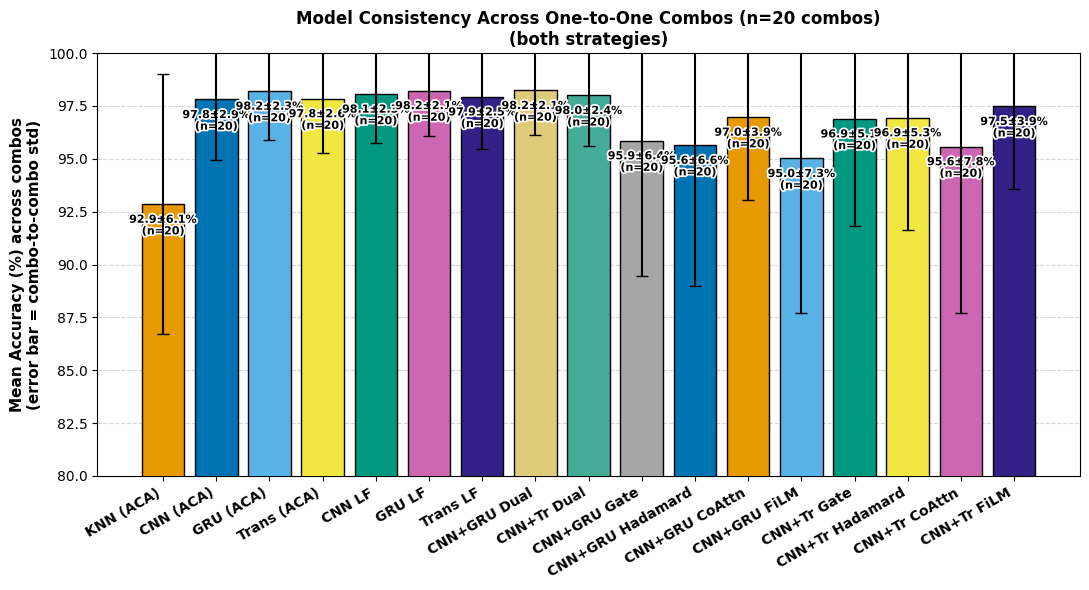

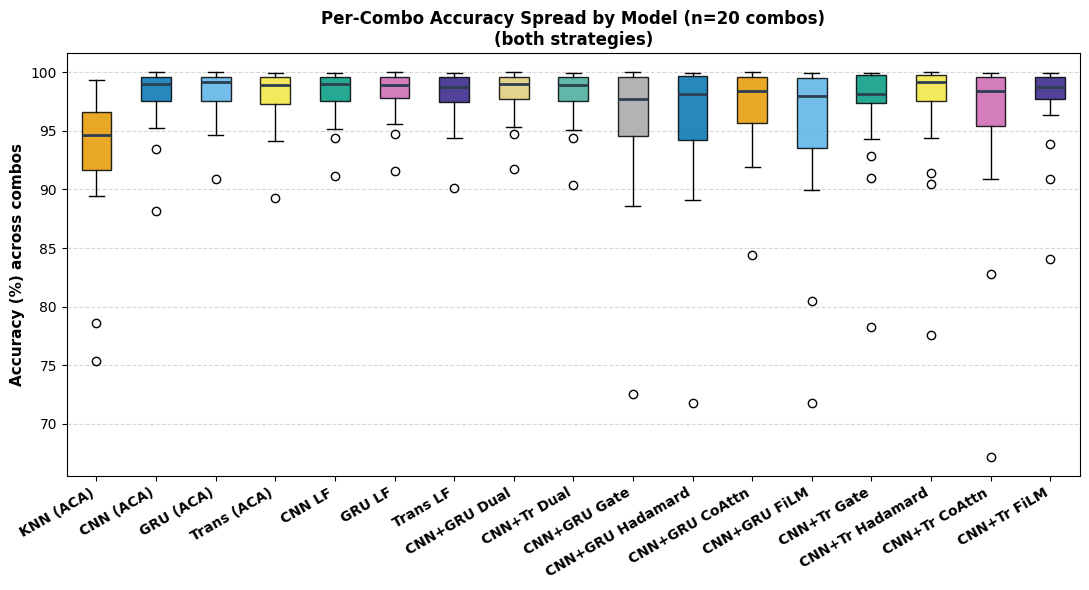

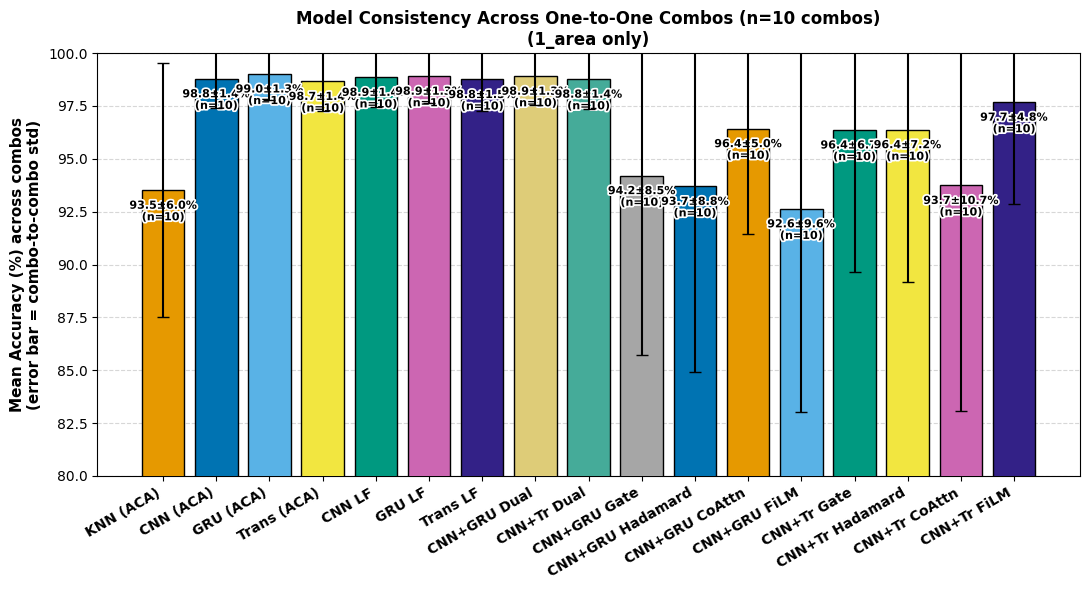

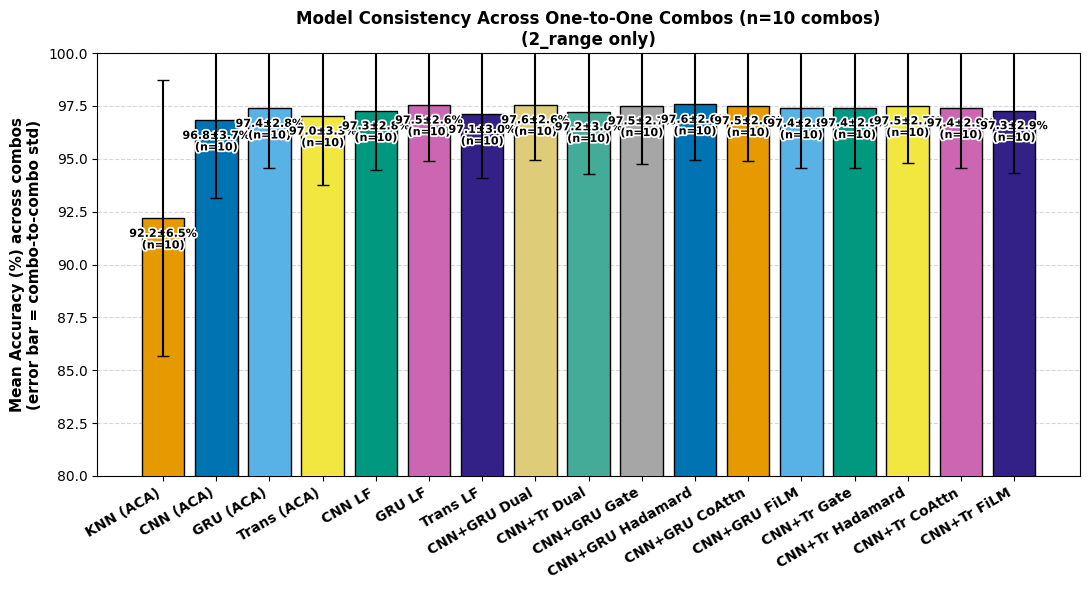

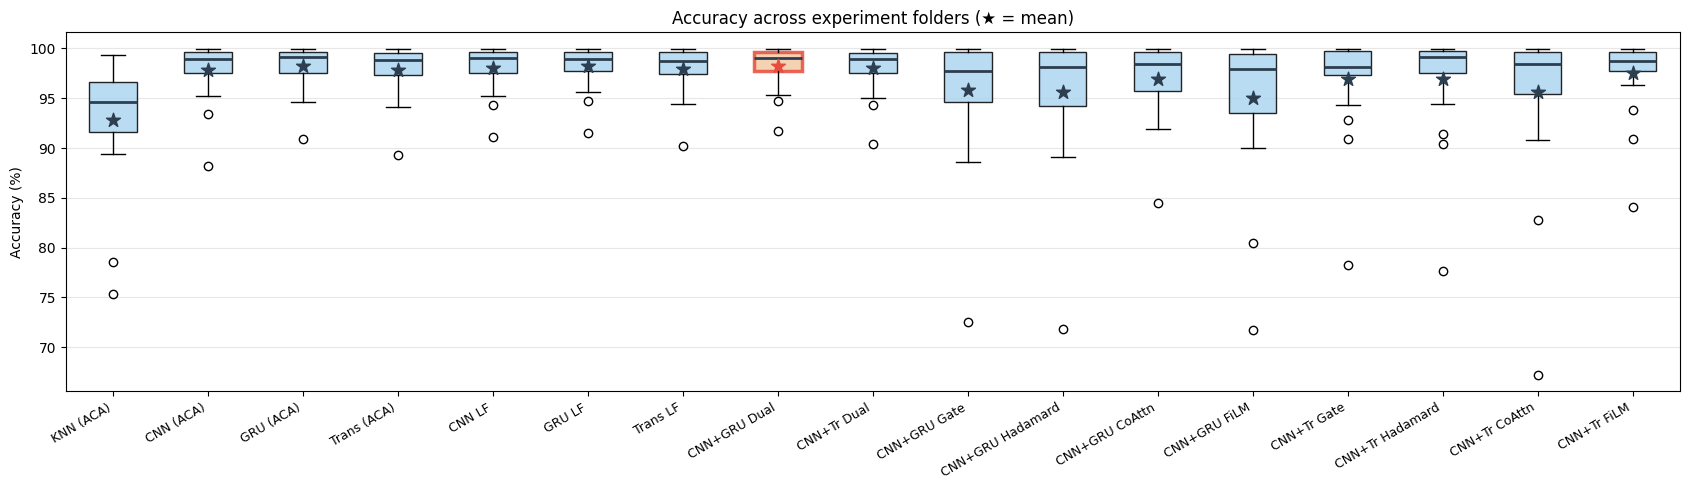

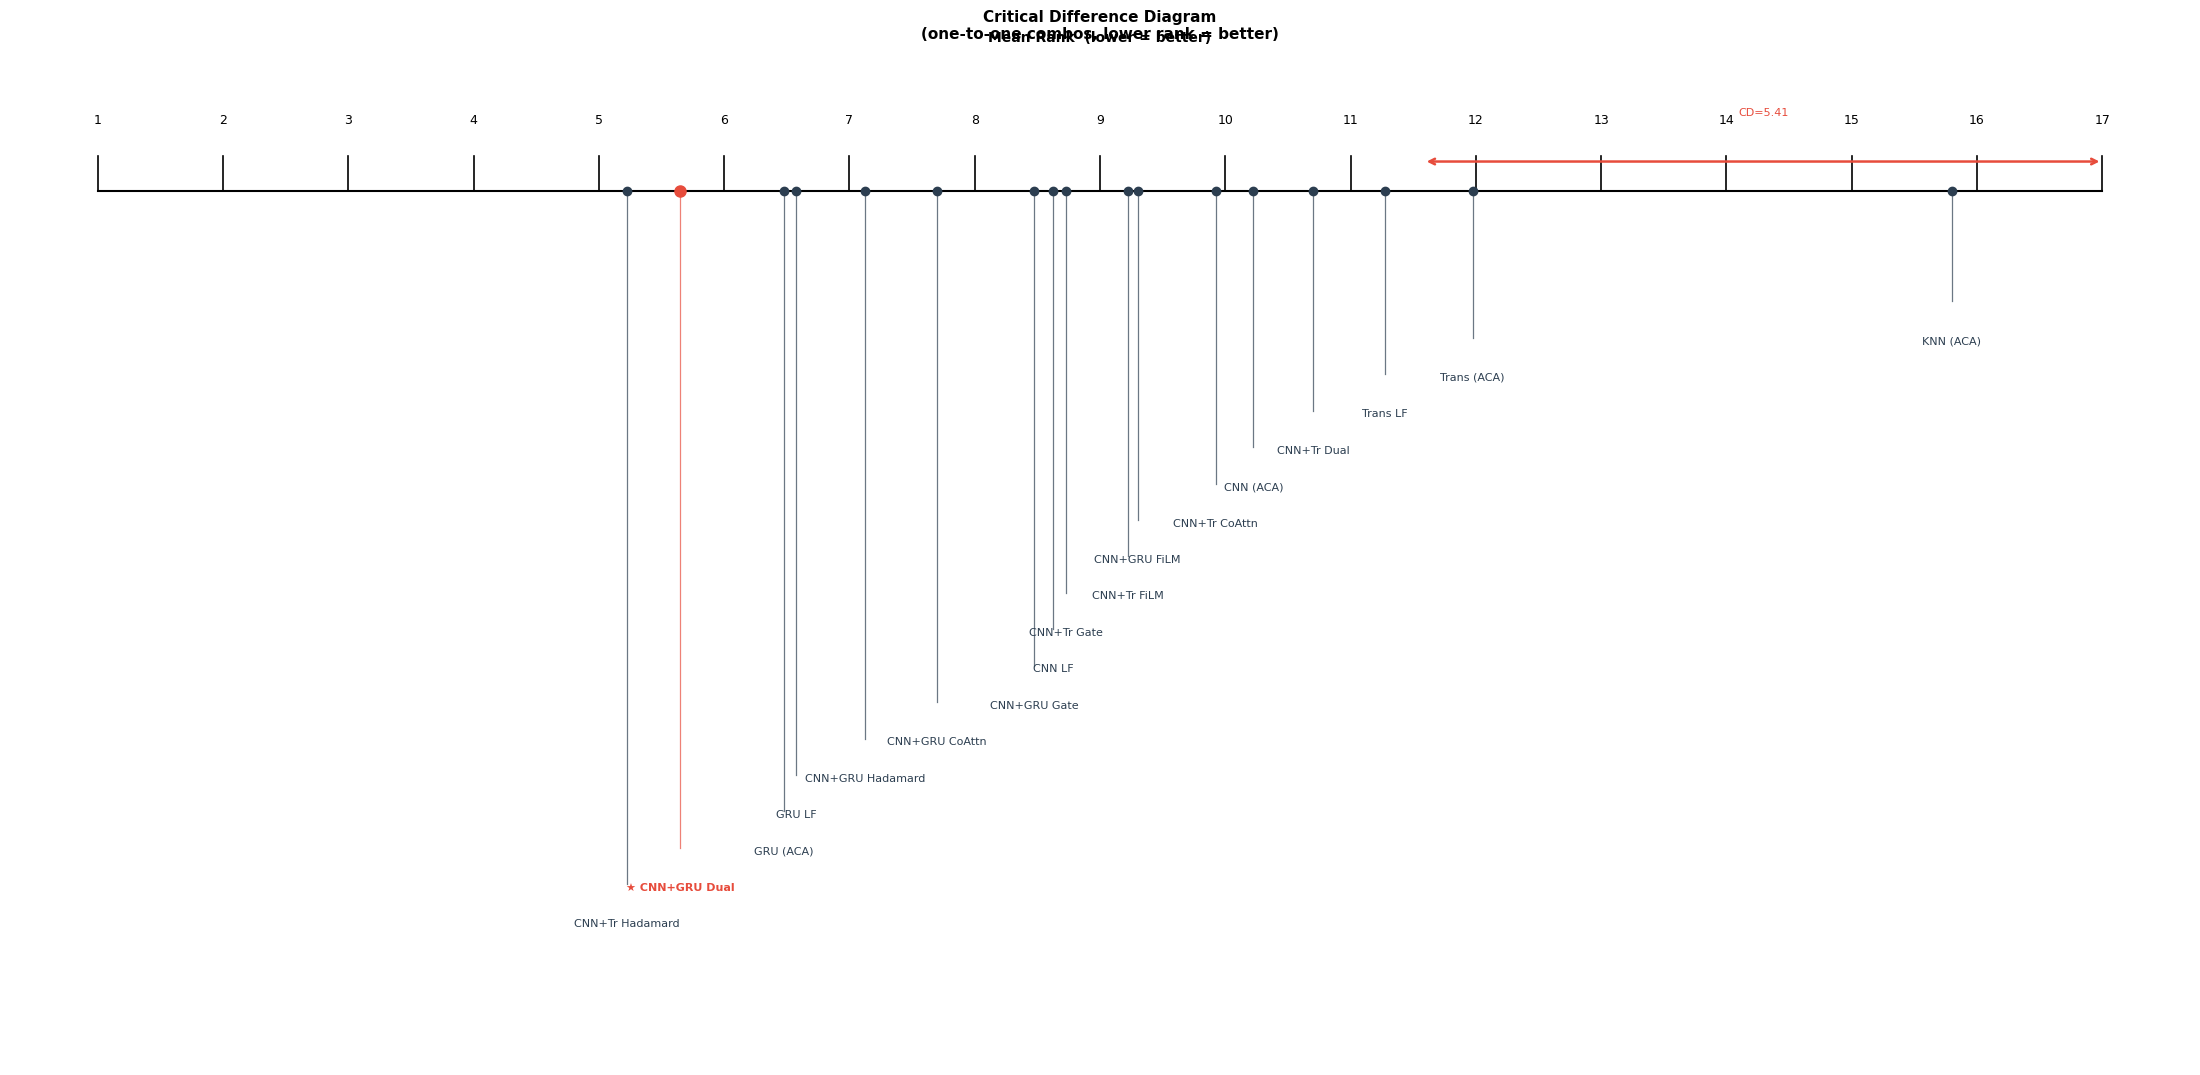

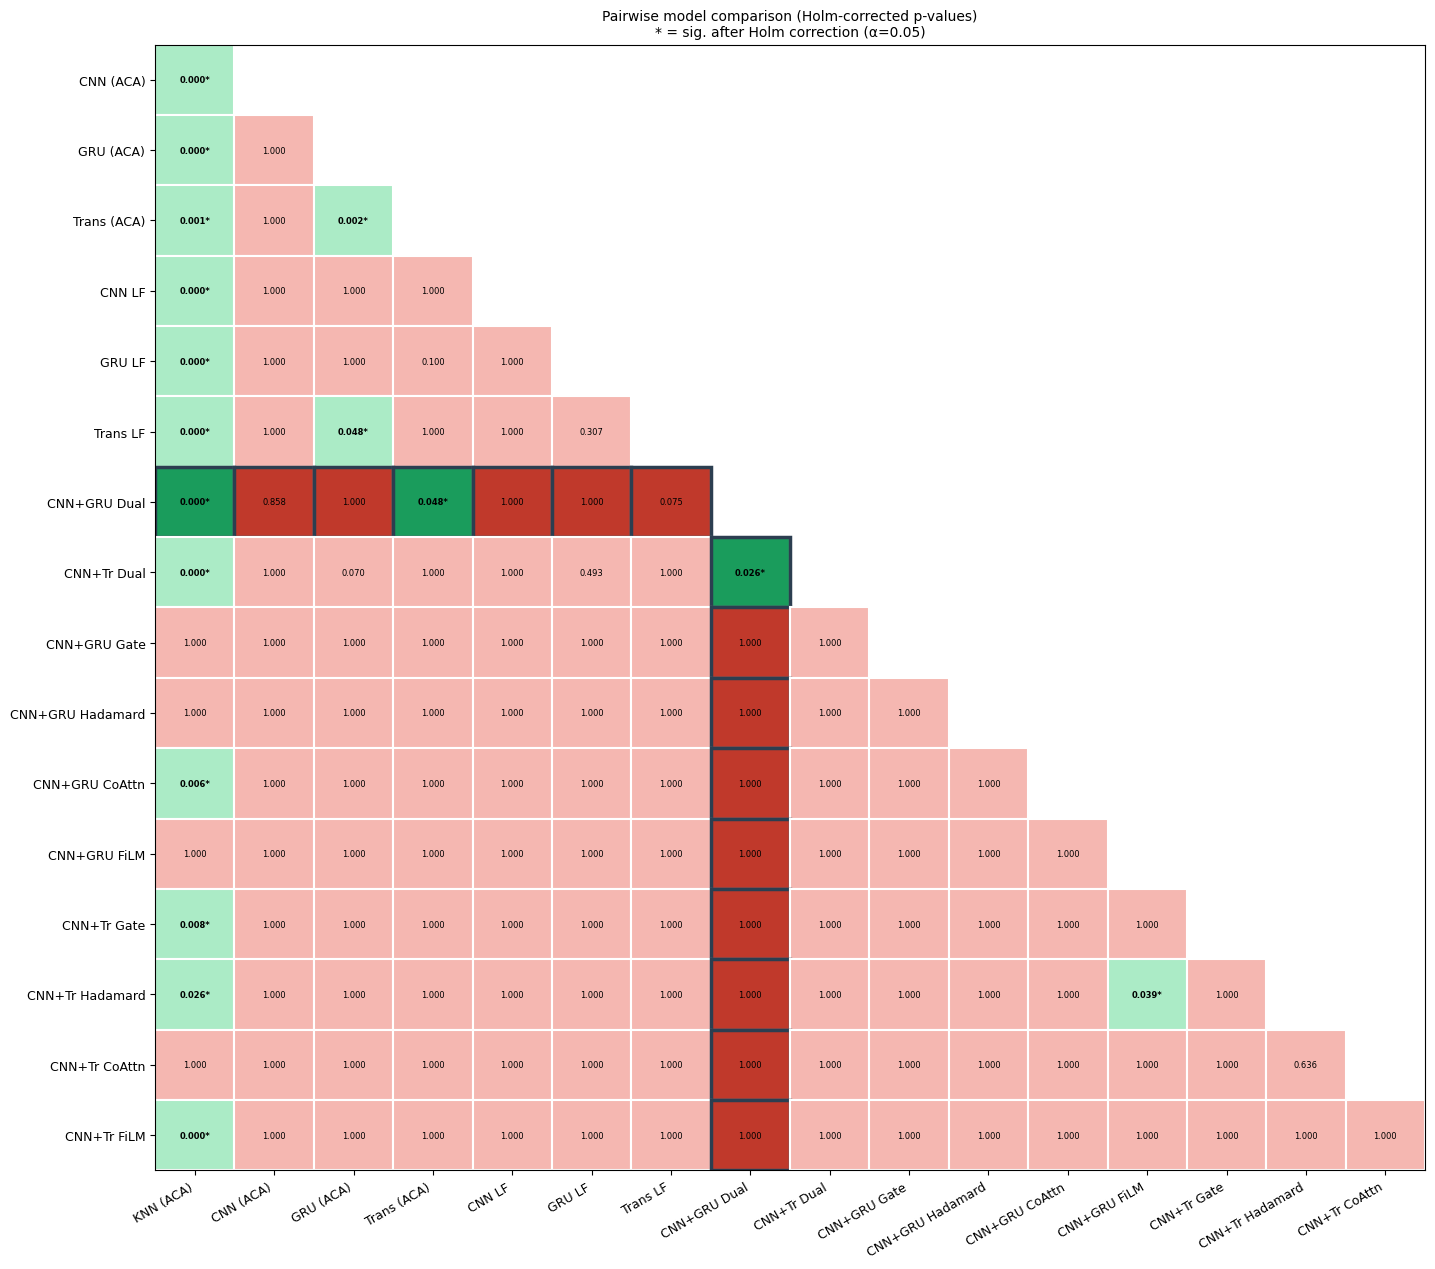

In [70]:
%matplotlib inline
if "error" not in stats:
    stat08.plot_accuracy_boxplot(matrix, model_names, metric_name="Accuracy", baseline_idx=baseline_idx)
    stat08.plot_cd_diagram(stats["avg_ranks"], stats["cd"], model_names, baseline_idx=baseline_idx,
                          title="Critical Difference Diagram\n(one-to-one combos, lower rank = better)")
    stat08.plot_pvalue_heatmap(stats["adj_mat"], stats["rej_mat"], model_names, baseline_idx=baseline_idx,
                              title="Pairwise model comparison (Holm-corrected p-values)")

## 6. Goal 3: `1_area` vs `2_range` consistency for the same target pairs

Both strategies classify the exact same 10 label pairs -- this checks whether they agree
on which pairs/models perform well, the strategy-comparison counterpart to Section 4's
model-comparison view.

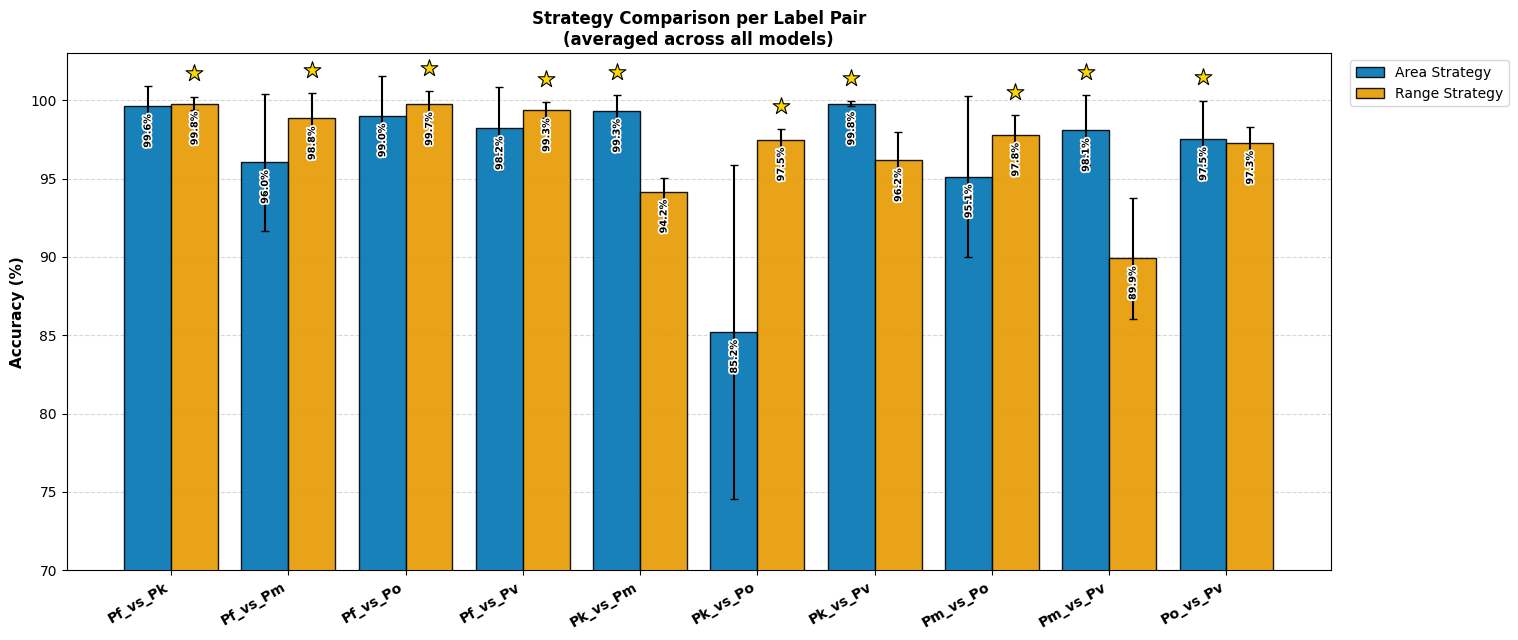

In [71]:
def grouped_bar_chart(df, x_col, x_order, hue_col, hue_order, color_map, label_map, title, figsize=None):
    n_groups = len(hue_order)
    bar_width = 0.8 / n_groups
    x = np.arange(len(x_order))
    fig, ax = plt.subplots(figsize=figsize or (max(11, len(x_order) * 1.6 + 2), 6.5))

    all_vals = []
    bar_records = []  # (group_idx, xi, key, mean, std) for every bar, used to find the per-group best
    for i, key in enumerate(hue_order):
        means, stds = [], []
        for xv in x_order:
            row = df[(df[x_col] == xv) & (df[hue_col] == key)]
            means.append(row["accuracy_mean"].mean() if not row.empty else np.nan)
            stds.append(row["accuracy_mean"].std() if len(row) > 1 else 0)
        means_arr, stds_arr = np.array(means), np.array(stds)
        all_vals.extend(means_arr[~np.isnan(means_arr)].tolist())
        offset = (i - n_groups / 2 + 0.5) * bar_width
        xi_positions = x + offset
        ax.bar(xi_positions, np.nan_to_num(means_arr, nan=0.0), width=bar_width, yerr=stds_arr,
               capsize=3, label=label_map.get(key, str(key)), color=color_map.get(key, "#ccc"),
               edgecolor="black", linewidth=1, alpha=0.9, zorder=3)
        for xi, m in zip(xi_positions, means_arr):
            if not np.isnan(m):
                ax.text(xi, m - 0.5, f"{m:.1f}%", ha="center", va="top", fontsize=7,
                         fontweight="bold", rotation=90, path_effects=_TEXT_OUTLINE, zorder=4)
        for j, (xi, m, s) in enumerate(zip(xi_positions, means_arr, stds_arr)):
            bar_records.append((j, xi, key, m, s))

    # star above the highest hue value within each x-group
    for j in range(len(x_order)):
        group_bars = [(xi, m, s) for (gj, xi, key, m, s) in bar_records if gj == j and not np.isnan(m)]
        if not group_bars:
            continue
        best_xi, best_m, best_s = max(group_bars, key=lambda t: t[1])
        ax.scatter(best_xi, best_m + best_s + 1.5, marker="*", s=160, color="gold",
                   edgecolor="black", linewidth=0.8, zorder=5)

    valid = [v for v in all_vals if not np.isnan(v)]
    ymin = max(0, (min(valid) // 10) * 10 - 10) if valid else 0
    ax.set_ylim(ymin, 103)
    ax.set_xticks(x)
    ax.set_xticklabels(x_order, rotation=30, ha="right", fontweight="bold")
    ax.set_ylabel("Accuracy (%)", fontsize=11, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
    fig.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

# Averaged across all models, per pair
grouped_bar_chart(results_df, "pair", PAIRS, "strategy", STRATEGIES, STRATEGY_COLOR_MAP, STRATEGY_LABEL_MAP,
                   "Strategy Comparison per Label Pair\n(averaged across all models)")

In [72]:
STRATEGIES

['1_area', '2_range']

In [73]:
MODELS

['knn',
 'cnn',
 'gru',
 'transformer',
 'cnn_lf',
 'gru_lf',
 'trans_lf',
 'cnn_gru_dual',
 'cnn_trans_dual',
 'cnn_gru_gate',
 'cnn_gru_hadamard',
 'cnn_gru_crossattn',
 'cnn_gru_film',
 'cnn_trans_gate',
 'cnn_trans_hadamard',
 'cnn_trans_crossattn',
 'cnn_trans_film']

In [74]:
results_df

,combo,strategy,pair,model,accuracy_mean,accuracy_std,n_folds
0,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,knn,94.695431,0.668626,5
1,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,cnn,99.898477,0.050761,5
2,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,gru,99.974619,0.050761,5
3,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,transformer,99.873096,0.080261,5
4,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,cnn_lf,99.949239,0.062170,5
...,...,...,...,...,...,...,...
335,2_range__Po_vs_Pv,2_range,Po_vs_Pv,cnn_gru_film,97.655123,0.337644,5
336,2_range__Po_vs_Pv,2_range,Po_vs_Pv,cnn_trans_gate,97.821068,0.134207,5
337,2_range__Po_vs_Pv,2_range,Po_vs_Pv,cnn_trans_hadamard,97.900433,0.342542,5
338,2_range__Po_vs_Pv,2_range,Po_vs_Pv,cnn_trans_crossattn,97.705628,0.254681,5


In [75]:
sub = results_df[results_df.strategy == '1_area']

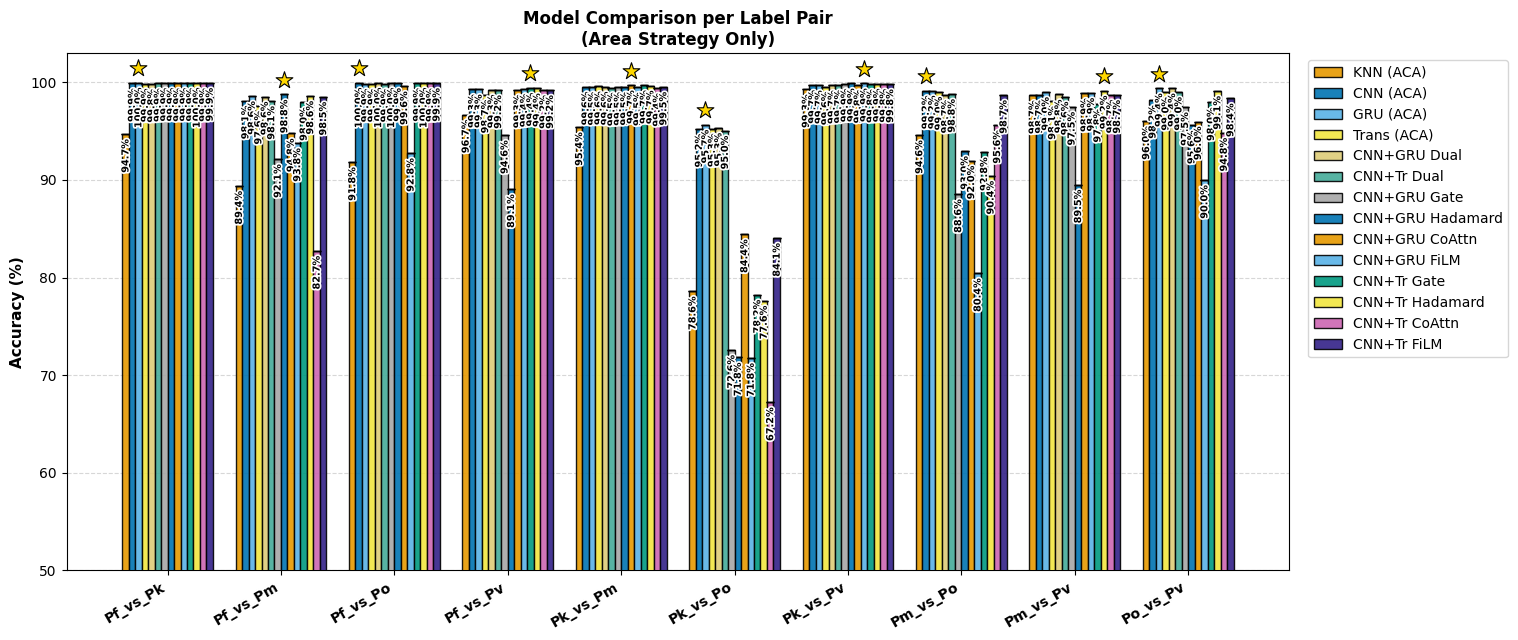

In [76]:
grouped_bar_chart(sub, "pair", PAIRS, "model", MODELS[:4]+MODELS[7:],  MODEL_COLOR_MAP, MODEL_LABEL_MAP,
                    f"Model Comparison per Label Pair\n(Area Strategy Only)")

In [77]:
MODELS

['knn',
 'cnn',
 'gru',
 'transformer',
 'cnn_lf',
 'gru_lf',
 'trans_lf',
 'cnn_gru_dual',
 'cnn_trans_dual',
 'cnn_gru_gate',
 'cnn_gru_hadamard',
 'cnn_gru_crossattn',
 'cnn_gru_film',
 'cnn_trans_gate',
 'cnn_trans_hadamard',
 'cnn_trans_crossattn',
 'cnn_trans_film']

In [78]:
PAIRS

['Pf_vs_Pk',
 'Pf_vs_Pm',
 'Pf_vs_Po',
 'Pf_vs_Pv',
 'Pk_vs_Pm',
 'Pk_vs_Po',
 'Pk_vs_Pv',
 'Pm_vs_Po',
 'Pm_vs_Pv',
 'Po_vs_Pv']

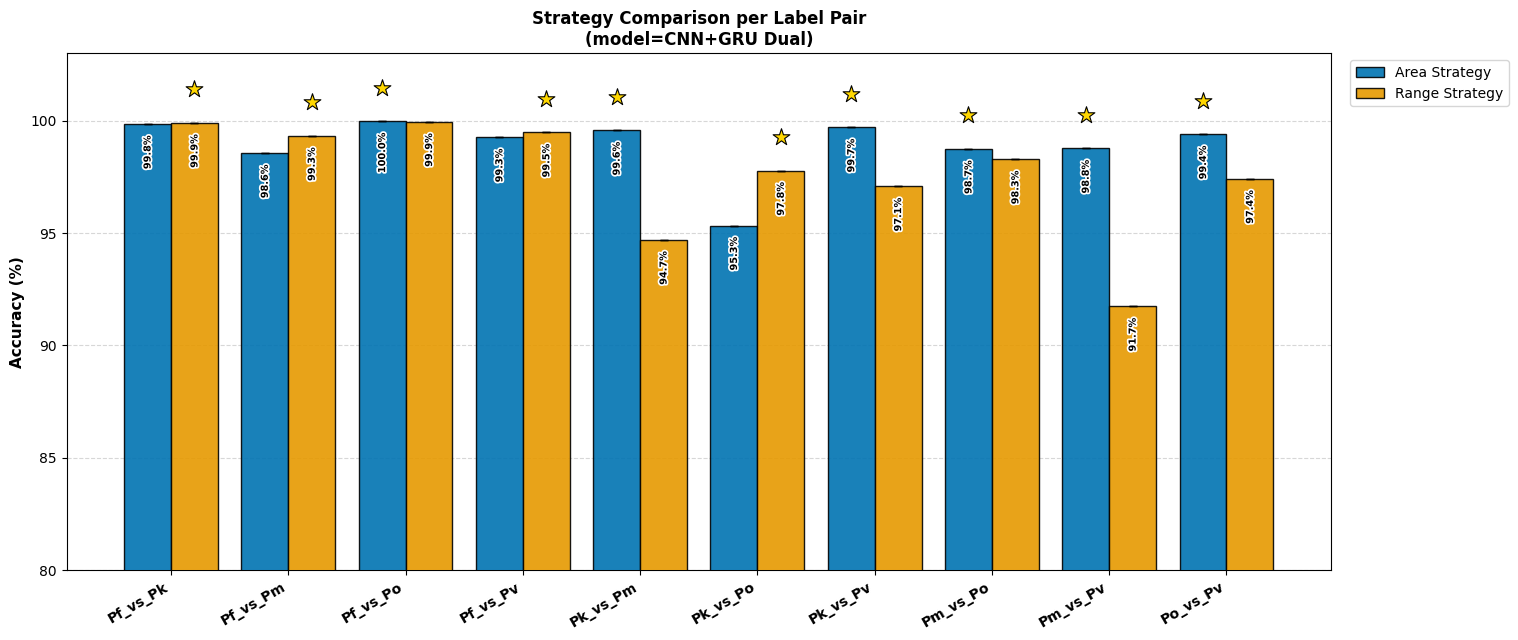

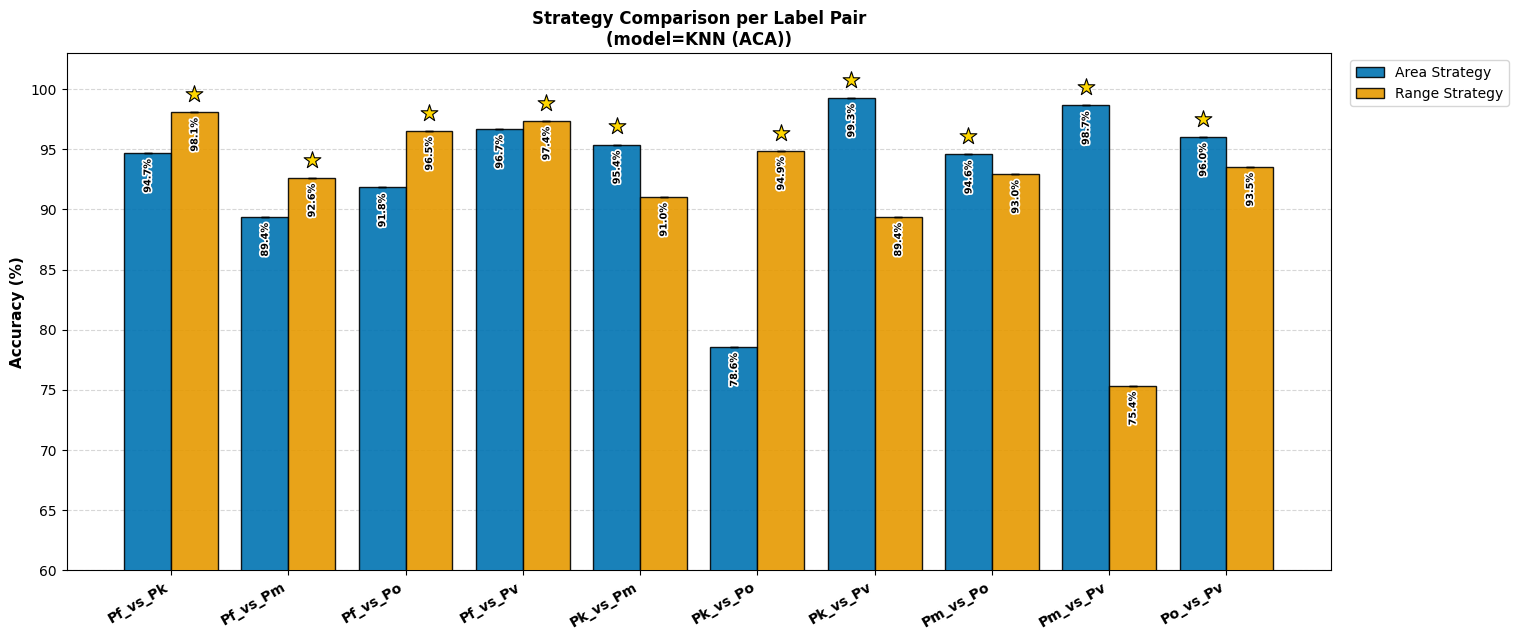

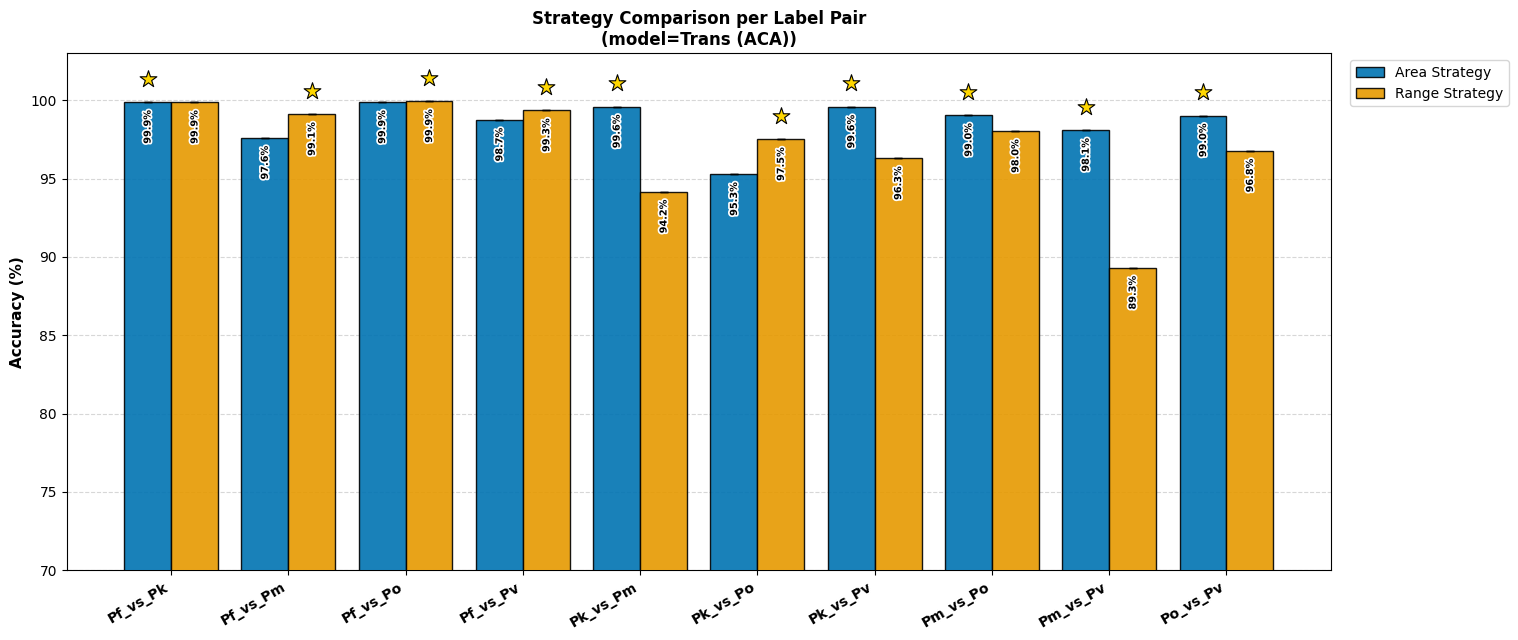

In [79]:
%matplotlib inline
# Same, for one specific model at a time
for model in ["cnn_gru_dual", "knn", "transformer"]:
    sub = results_df[results_df.model == model]
    grouped_bar_chart(sub, "pair", PAIRS, "strategy", STRATEGIES, STRATEGY_COLOR_MAP, STRATEGY_LABEL_MAP,
                       f"Strategy Comparison per Label Pair\n(model={MODEL_LABEL_MAP.get(model, model)})")

### Strategy agreement: correlation + paired significance test

If the two strategies "agree", a (pair, model) combo that scores high under `1_area`
should also score high under `2_range`. Pearson correlation across every matched
(pair, model) point gives a single consistency number; the paired Wilcoxon test (treating
each (pair, model) as one matched observation) checks whether one strategy is
systematically, significantly better than the other -- not just different on average.

Matched (pair, model) observations: 170
Pearson correlation between 1_area and 2_range accuracy: -0.021


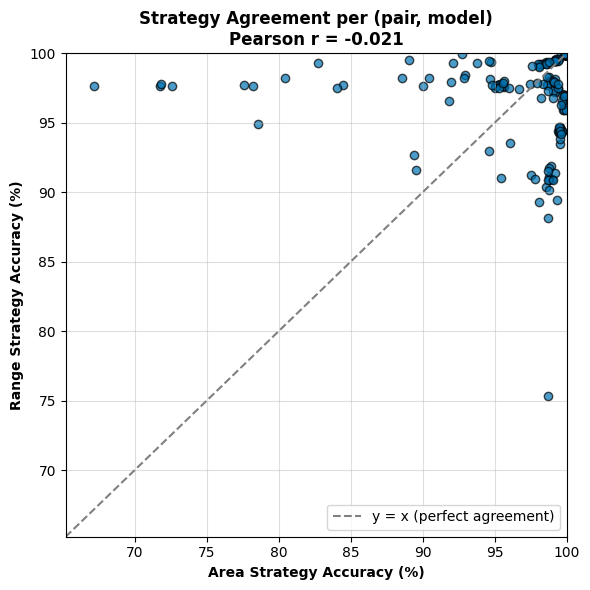


Paired Wilcoxon (1_area vs 2_range): W=6450.00, p=0.2034 -> not significant difference
Mean (1_area - 2_range): -0.26pp, std: 6.81pp


In [80]:
wide = results_df.pivot_table(index=["pair", "model"], columns="strategy", values="accuracy_mean")
wide = wide.dropna()
print(f"Matched (pair, model) observations: {len(wide)}")

corr = wide["1_area"].corr(wide["2_range"])
print(f"Pearson correlation between 1_area and 2_range accuracy: {corr:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(wide["1_area"], wide["2_range"], alpha=0.7, edgecolor="black")
lims = [min(wide.min()) - 2, 100]
ax.plot(lims, lims, "--", color="gray", label="y = x (perfect agreement)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Area Strategy Accuracy (%)", fontweight="bold")
ax.set_ylabel("Range Strategy Accuracy (%)", fontweight="bold")
ax.set_title(f"Strategy Agreement per (pair, model)\nPearson r = {corr:.3f}", fontweight="bold")
ax.legend()
ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

from scipy.stats import wilcoxon
w_stat, w_p = wilcoxon(wide["1_area"], wide["2_range"], alternative="two-sided", zero_method="pratt")
diff = wide["1_area"] - wide["2_range"]
print(f"\nPaired Wilcoxon (1_area vs 2_range): W={w_stat:.2f}, p={w_p:.4f}"
      f" -> {'SIGNIFICANT' if w_p < 0.05 else 'not significant'} difference")
print(f"Mean (1_area - 2_range): {diff.mean():+.2f}pp, std: {diff.std():.2f}pp")

In [81]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import config

def plot_curve_for_training_by_target(exp_folder, folder_index):
    """Visualizes curve_for_training.joblib's curves as a line chart: x=timestamp/cycle,
    hue=target, line=mean curve per target group (shaded band=+/-1 std).
    """
    folder_names = sorted([
        name for name in os.listdir(exp_folder)
        if os.path.isdir(os.path.join(exp_folder, name)) and name not in config.EXCLUDED_FOLDERS
    ])
    if folder_index >= len(folder_names):
        raise IndexError(f"folder_index {folder_index} out of bounds for {len(folder_names)} folders: {folder_names}")
    folder_name = folder_names[folder_index]
    data_path = os.path.join(exp_folder, folder_name, config.TRAINING_DATA_PATH)
    data = joblib.load(data_path)

    curves = data["curves"]["ori_curves"]
    timestamps = data["timestamps"]
    well_labels = np.asarray(data["well_labels"])

    fig, ax = plt.subplots(figsize=(12, 7))
    for target in sorted(set(well_labels)):
        mask = well_labels == target
        mean_curve = curves[mask].mean(axis=0)
        std_curve = curves[mask].std(axis=0)
        line, = ax.plot(timestamps, mean_curve, label=f"{target} (n={mask.sum()})", lw=2)
        ax.fill_between(timestamps, mean_curve - std_curve, mean_curve + std_curve,
                         color=line.get_color(), alpha=0.05)

    ax.set_xlabel("Timestamp / Cycle", fontsize=11, fontweight="bold")
    ax.set_ylabel("Signal", fontsize=11, fontweight="bold")
    ax.set_title(f"{folder_name}: Mean Curve ± Std by Target", fontsize=13, fontweight="bold")
    ax.legend(title="Target", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

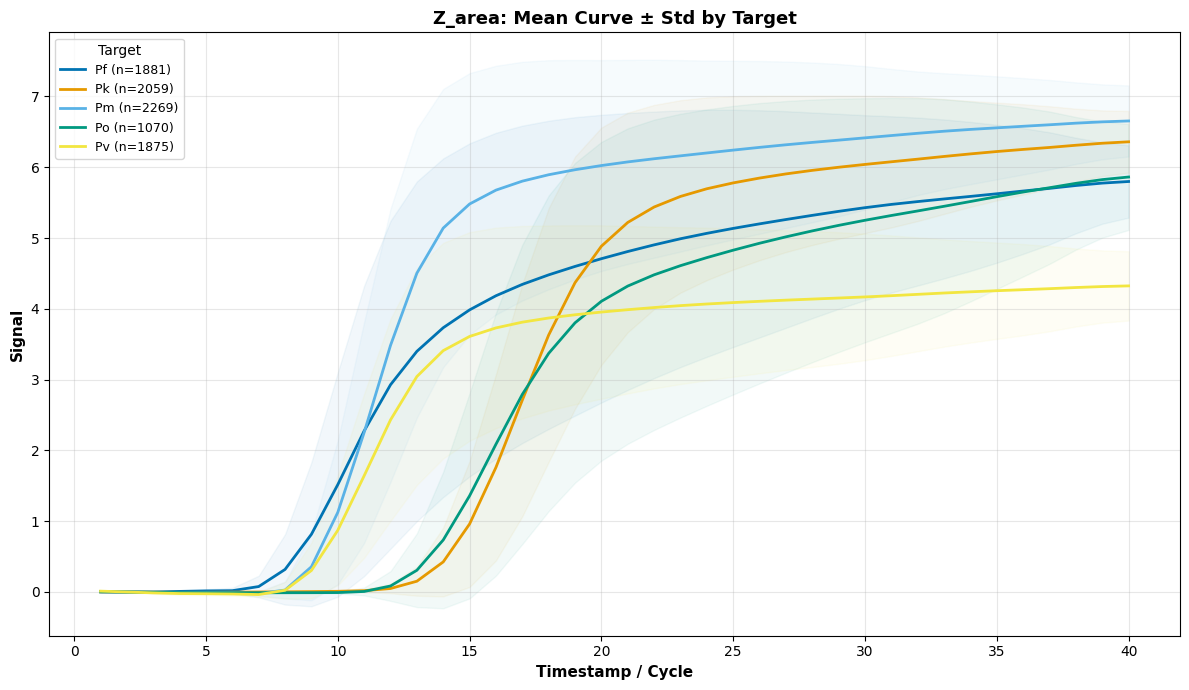

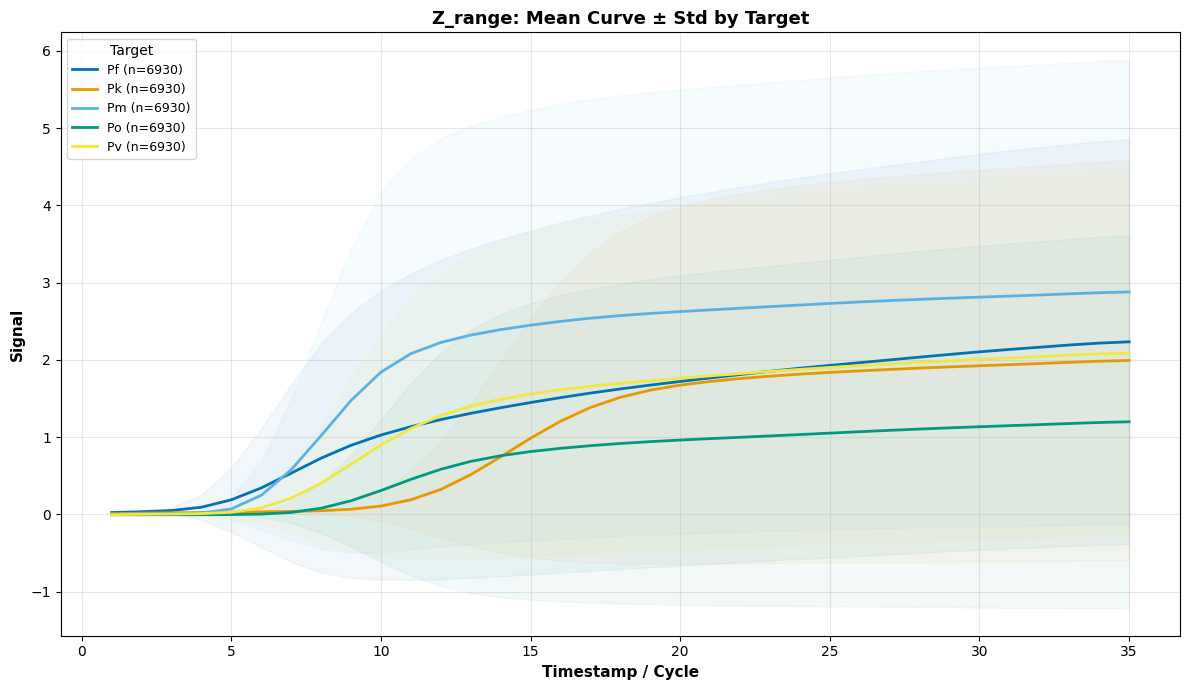

In [82]:
plot_curve_for_training_by_target(config.LAB_EXP_FOLDER, folder_index=3)
plot_curve_for_training_by_target(config.LAB_EXP_FOLDER, folder_index=4)

In [83]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib.util
import config

# Reuse 01b_lab_curve_preprocessing.py's FILE_MAPPING / FILE_TARGET / _read_table / get_numeric_sort_key
spec = importlib.util.spec_from_file_location(
    "lab01b", "/vol/bitbucket/gk225/POC_DDM/gk_code/main/01b_lab_curve_preprocessing.py"
)
lab01b = importlib.util.module_from_spec(spec)
spec.loader.exec_module(lab01b)

In [84]:
def plot_raw_curves_by_well(exp_folder, folder_index, normalize=False):
    """Reads area_strategy.csv/range_strategy.xlsx directly (LAB_DDM_paper raw source files,
    not curve_for_training.joblib). Plots ONE LINE PER WELL (averaged across that well's dPCR
    partition rows), coloured by Target label. Well-identifier column is 'Well' on
    area_strategy, 'Channel' on range_strategy -- detected dynamically.
    If normalize=True, each raw curve (each row, independently) is min-max scaled to [0,1]
    before being averaged into its well's mean curve.
    """
    folder_names = sorted([
        name for name in os.listdir(exp_folder)
        if os.path.isdir(os.path.join(exp_folder, name)) and name not in config.EXCLUDED_FOLDERS
    ])
    if folder_index >= len(folder_names):
        raise IndexError(f"folder_index {folder_index} out of bounds for {len(folder_names)} folders: {folder_names}")
    folder_name = folder_names[folder_index]
    file_path = os.path.join(exp_folder, folder_name, lab01b.FILE_MAPPING[folder_name])
    df = lab01b._read_table(file_path)

    well_col = "Well" if "Well" in df.columns else "Channel"
    target_col = lab01b.FILE_TARGET[folder_name]

    cycle_cols = [col for col in df.columns
                  if str(col).startswith("Cycle") or re.match(r'^\d+(\.\d+)?$', str(col))]
    sorted_cycle_cols = sorted(cycle_cols, key=lab01b.get_numeric_sort_key)
    timestamps = np.array([lab01b.get_numeric_sort_key(c) for c in sorted_cycle_cols])

    curve_vals_all = df[sorted_cycle_cols].to_numpy().astype(np.float64)
    if normalize:
        row_min = curve_vals_all.min(axis=1, keepdims=True)
        row_max = curve_vals_all.max(axis=1, keepdims=True)
        denom = np.where(row_max - row_min == 0, 1, row_max - row_min)
        curve_vals_all = (curve_vals_all - row_min) / denom
    norm_df = pd.DataFrame(curve_vals_all, columns=sorted_cycle_cols, index=df.index)
    df = pd.concat([df[[well_col, target_col]], norm_df], axis=1)

    targets = sorted(df[target_col].unique())
    cmap = plt.get_cmap("tab10")
    color_map = {t: cmap(i % 10) for i, t in enumerate(targets)}

    fig, ax = plt.subplots(figsize=(12, 7))
    plotted_targets = set()
    for well_id, well_df in df.groupby(well_col):
        target = well_df[target_col].iloc[0]
        mean_curve = well_df[sorted_cycle_cols].mean(axis=0).to_numpy()
        std_curve = well_df[sorted_cycle_cols].std(axis=0).to_numpy()
        label = str(target) if target not in plotted_targets else None
        ax.plot(timestamps, mean_curve, color=color_map[target], lw=1.3, alpha=0.8, label=label)
        ax.fill_between(timestamps, mean_curve - std_curve, mean_curve + std_curve,
                             color=color_map[target], alpha=0.01, linewidth=0)
        plotted_targets.add(target)

    ax.set_xlabel("Cycle", fontsize=11, fontweight="bold")
    ax.set_ylabel("Signal (normalised)" if normalize else "Signal", fontsize=11, fontweight="bold")
    suffix = " (curve-wise normalised to [0,1])" if normalize else ""
    ax.set_title(f"{folder_name} ({well_col}-level curves, n={df[well_col].nunique()} wells){suffix}",
                 fontsize=13, fontweight="bold")
    ax.legend(title="Target", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


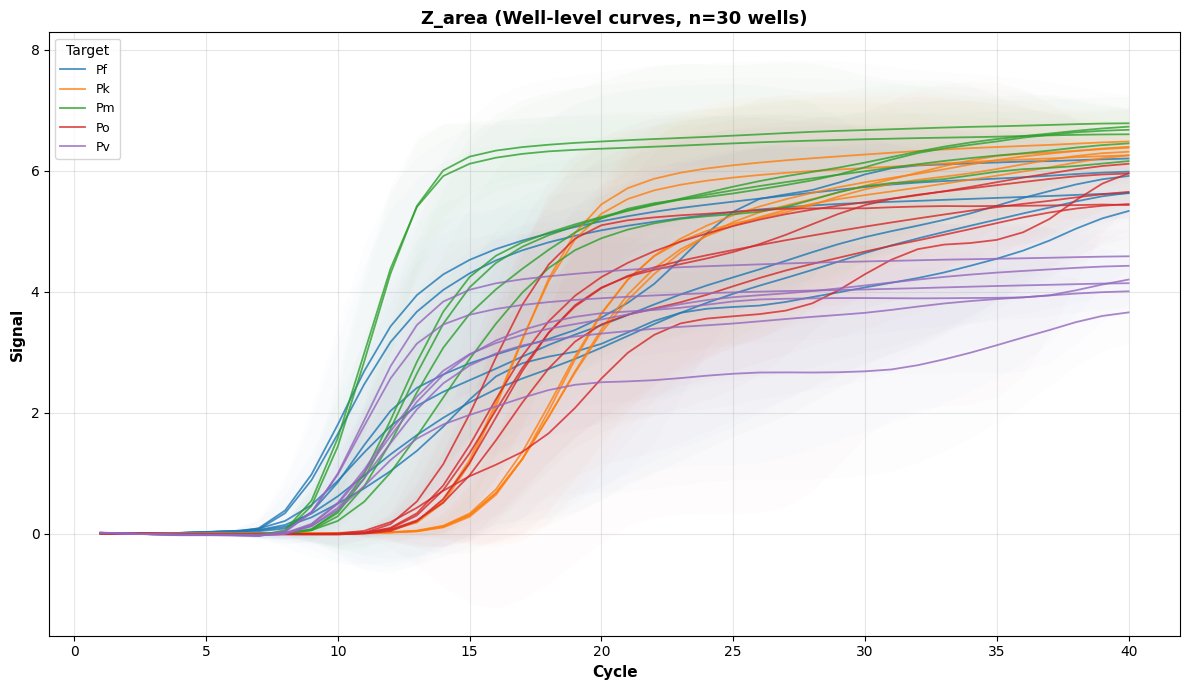

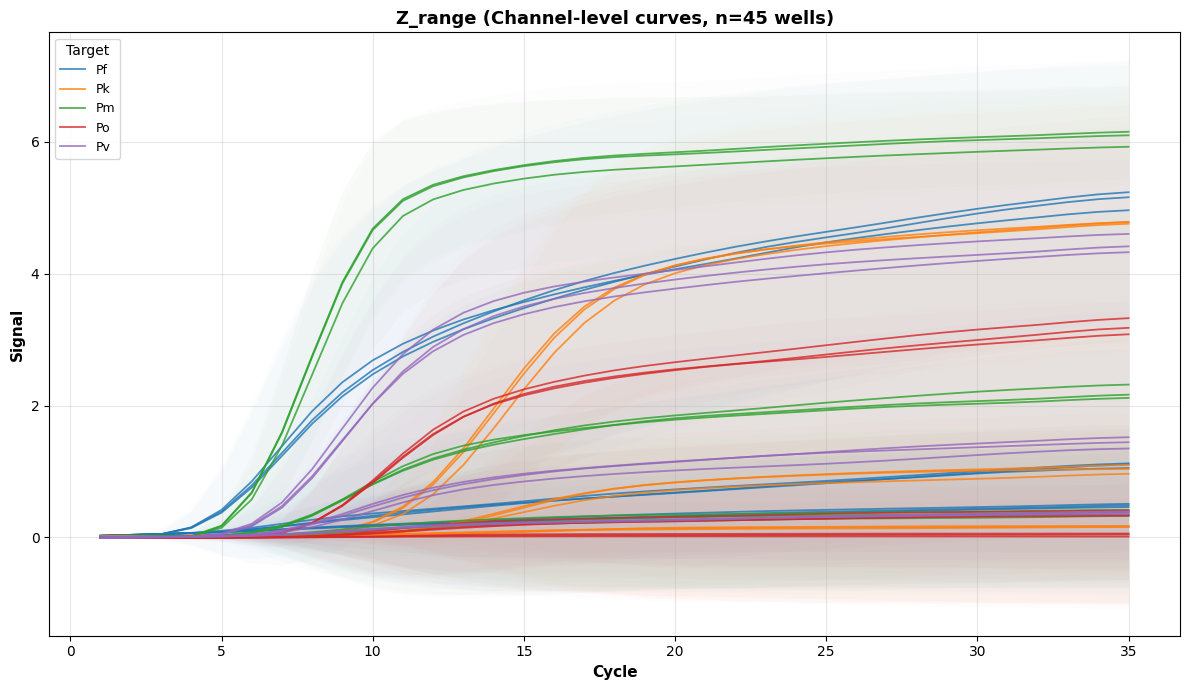

In [85]:
plot_raw_curves_by_well(config.LAB_EXP_FOLDER, folder_index=3)
plot_raw_curves_by_well(config.LAB_EXP_FOLDER, folder_index=4)

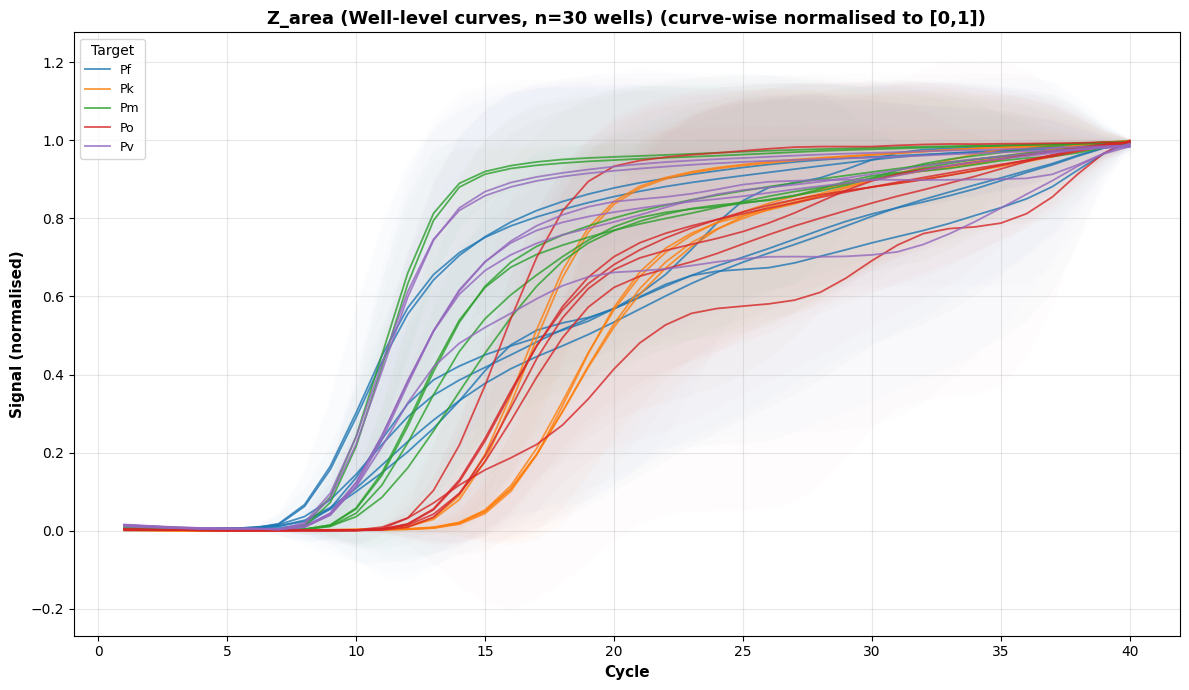

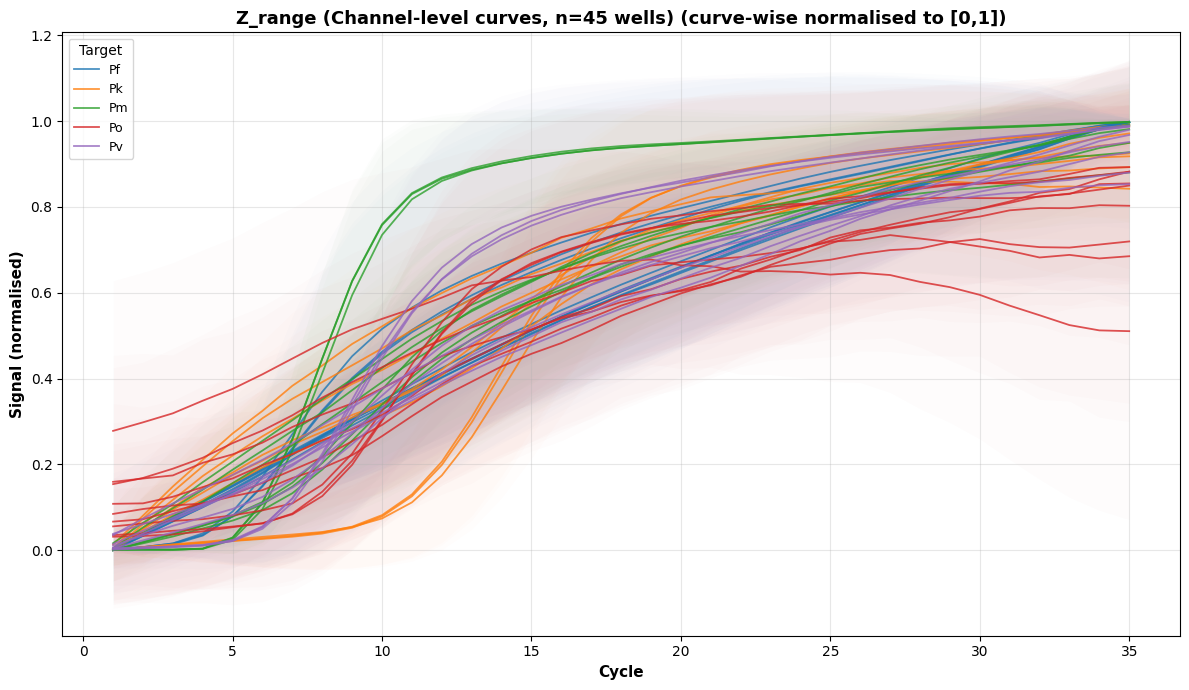

In [86]:
plot_raw_curves_by_well(config.LAB_EXP_FOLDER, folder_index=3, normalize=True)
plot_raw_curves_by_well(config.LAB_EXP_FOLDER, folder_index=4, normalize=True)

In [87]:
def plot_raw_curves_by_well_faceted(exp_folder, folder_index, normalize=False):
    """1 figure, 1 subplot per Target label, shared y-axis across subplots. Each subplot
    draws one line per well belonging to that label (mean across the well's dPCR partition
    rows), each well in its own distinct colour with a legend by well/channel number, plus
    a ±std shaded band (alpha=0.05). Reads area_strategy.csv/range_strategy.xlsx directly --
    well-identifier column is 'Well' on area_strategy, 'Channel' on range_strategy.
    If normalize=True, each raw curve (each row, independently) is min-max scaled to [0,1]
    before being averaged into its well's mean curve.
    """
    folder_names = sorted([
        name for name in os.listdir(exp_folder)
        if os.path.isdir(os.path.join(exp_folder, name)) and name not in config.EXCLUDED_FOLDERS
    ])
    if folder_index >= len(folder_names):
        raise IndexError(f"folder_index {folder_index} out of bounds for {len(folder_names)} folders: {folder_names}")
    folder_name = folder_names[folder_index]
    file_path = os.path.join(exp_folder, folder_name, lab01b.FILE_MAPPING[folder_name])
    df = lab01b._read_table(file_path)

    well_col = "Well" if "Well" in df.columns else "Channel"
    target_col = lab01b.FILE_TARGET[folder_name]

    cycle_cols = [col for col in df.columns
                  if str(col).startswith("Cycle") or re.match(r'^\d+(\.\d+)?$', str(col))]
    sorted_cycle_cols = sorted(cycle_cols, key=lab01b.get_numeric_sort_key)
    timestamps = np.array([lab01b.get_numeric_sort_key(c) for c in sorted_cycle_cols])

    curve_vals_all = df[sorted_cycle_cols].to_numpy().astype(np.float64)
    if normalize:
        row_min = curve_vals_all.min(axis=1, keepdims=True)
        row_max = curve_vals_all.max(axis=1, keepdims=True)
        denom = np.where(row_max - row_min == 0, 1, row_max - row_min)
        curve_vals_all = (curve_vals_all - row_min) / denom
    norm_df = pd.DataFrame(curve_vals_all, columns=sorted_cycle_cols, index=df.index)
    df = pd.concat([df[[well_col, target_col]], norm_df], axis=1)

    targets = sorted(df[target_col].unique())
    n = len(targets)
    ncols = min(5, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.8 * nrows), squeeze=False, sharey=True)
    axes_flat = axes.flatten()

    for i, target in enumerate(targets):
        ax = axes_flat[i]
        sub_df = df[df[target_col] == target]
        well_ids = sorted(sub_df[well_col].unique())
        well_cmap = plt.get_cmap("tab20", len(well_ids))
        well_color_map = {w: well_cmap(j) for j, w in enumerate(well_ids)}

        for well_id in well_ids:
            well_df = sub_df[sub_df[well_col] == well_id]
            curve_vals = well_df[sorted_cycle_cols].to_numpy()
            mean_curve = curve_vals.mean(axis=0)
            std_curve = curve_vals.std(axis=0)
            color = well_color_map[well_id]
            ax.plot(timestamps, mean_curve, color=color, lw=1.3, alpha=0.9, label=f"{well_col} {well_id}")
            ax.fill_between(timestamps, mean_curve - std_curve, mean_curve + std_curve,
                             color=color, alpha=0.05, linewidth=0)

        ax.set_title(f"{target} (n={len(well_ids)} wells)", fontsize=11, fontweight="bold")
        ax.set_xlabel("Cycle", fontsize=9)
        ax.set_ylabel("Signal (normalised)" if normalize else "Signal", fontsize=9)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=6, ncol=2, loc="upper left", framealpha=0.6)

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    suffix = " (curve-wise normalised to [0,1])" if normalize else ""
    fig.suptitle(f"{folder_name}: Per-Well Curves (±std) Faceted by Target{suffix}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


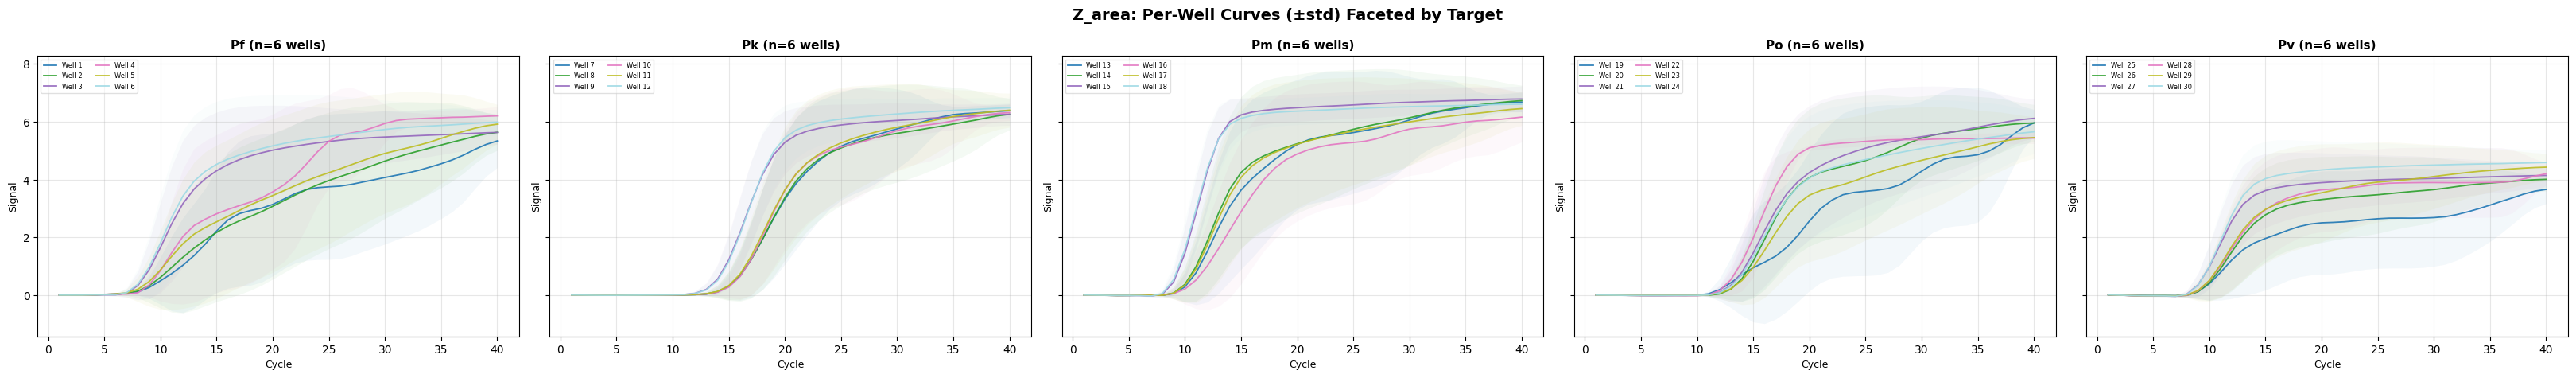

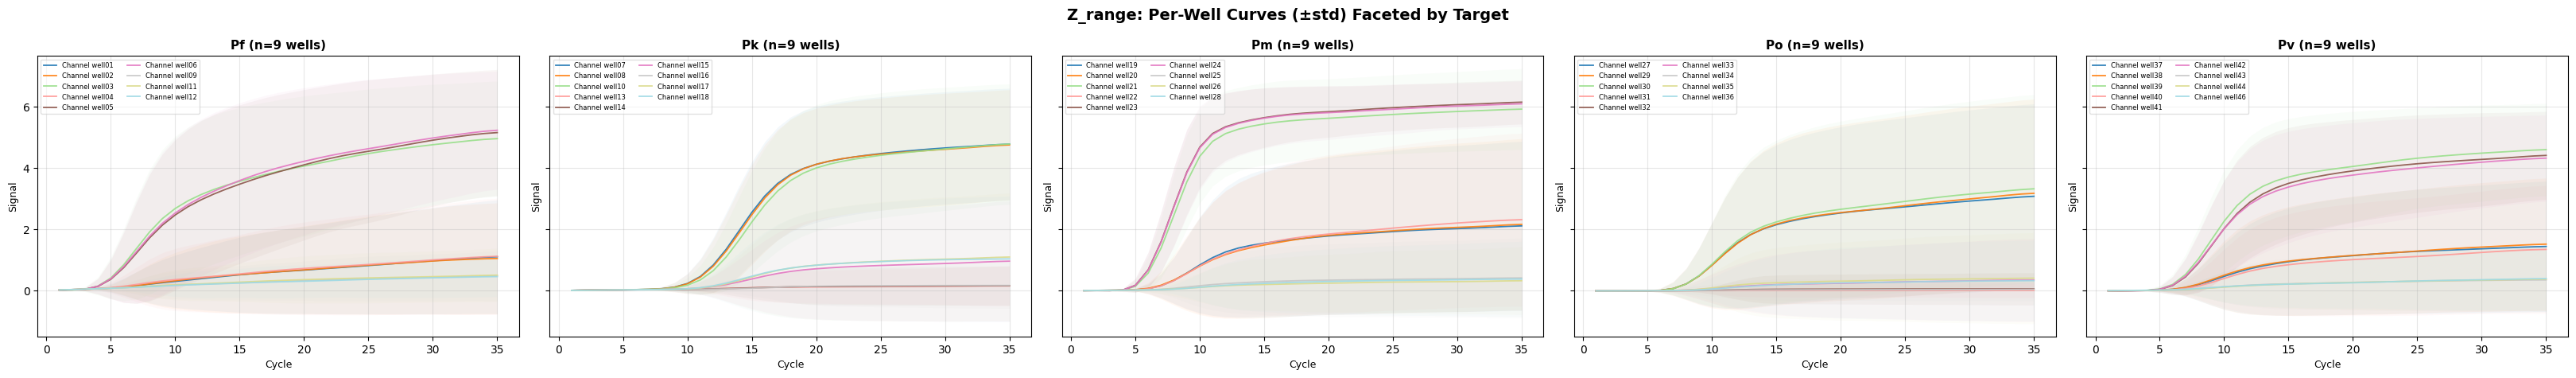

In [88]:
plot_raw_curves_by_well_faceted(config.LAB_EXP_FOLDER, folder_index=3)
plot_raw_curves_by_well_faceted(config.LAB_EXP_FOLDER, folder_index=4)

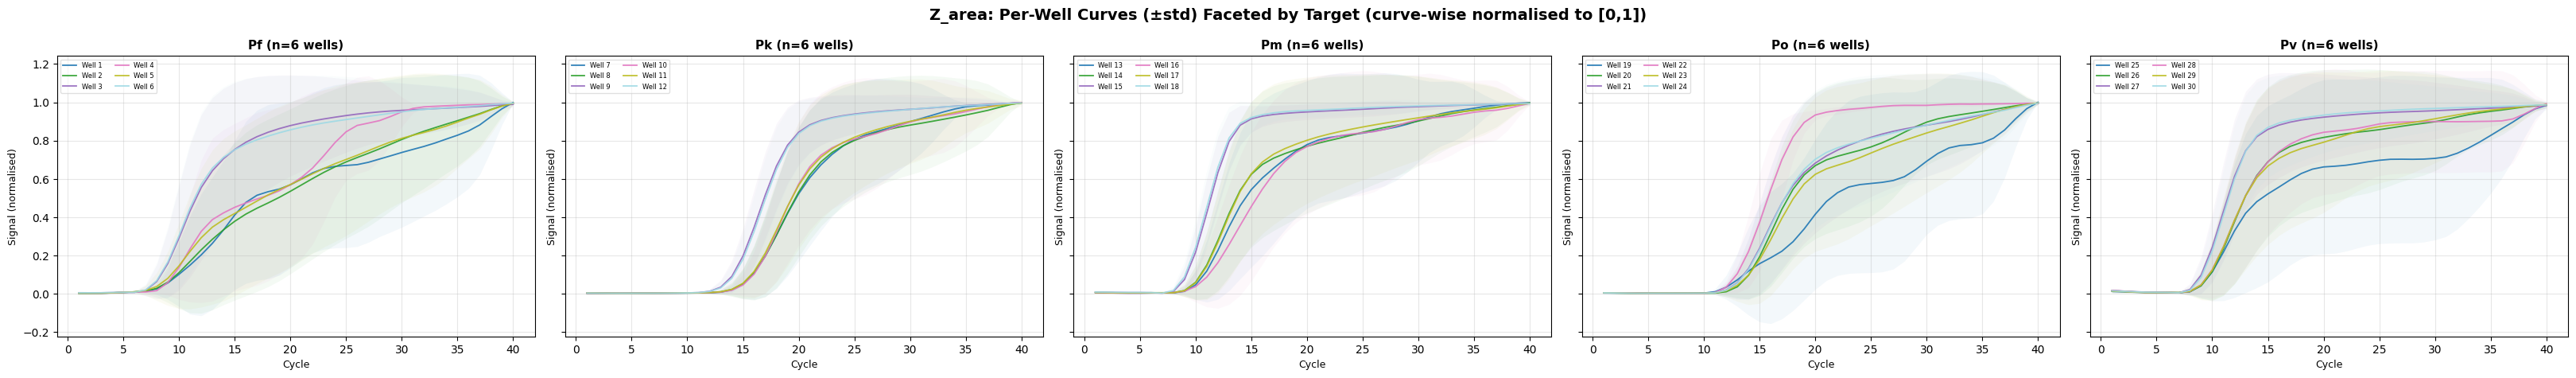

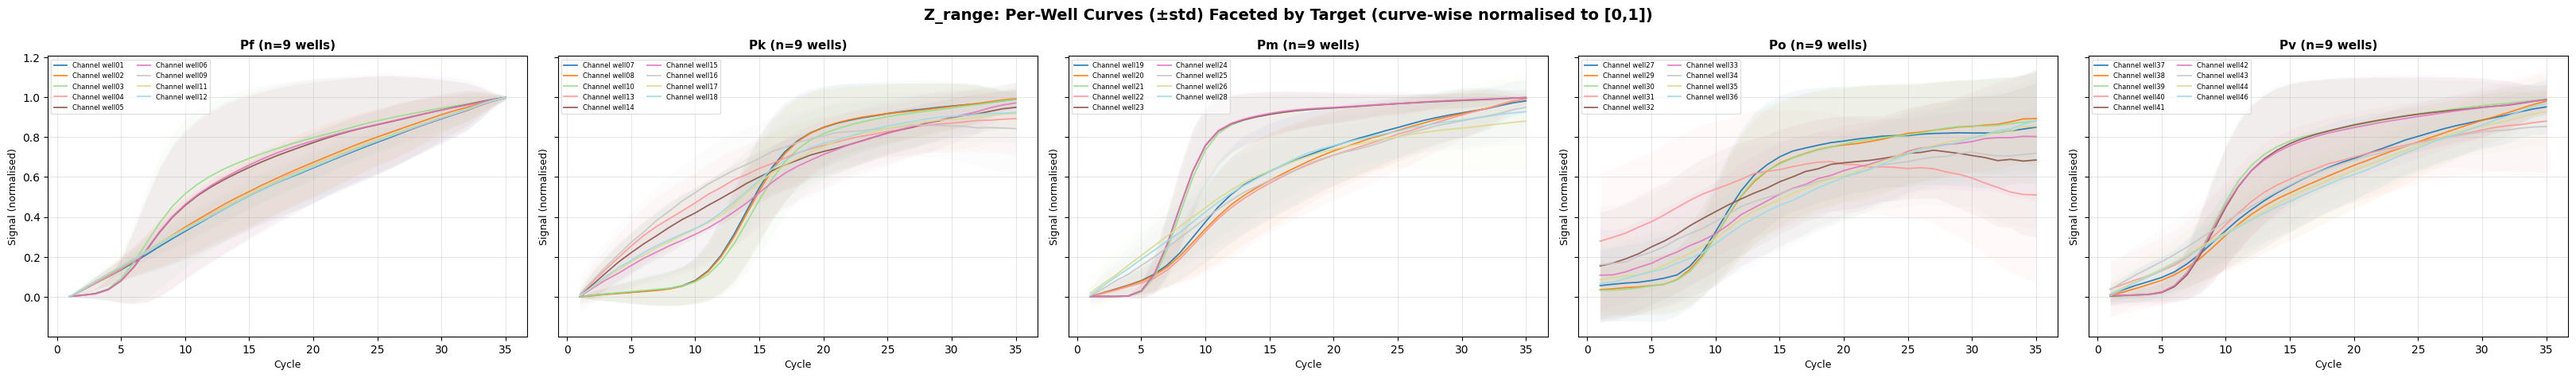

In [89]:
plot_raw_curves_by_well_faceted(config.LAB_EXP_FOLDER, folder_index=3, normalize=True)
plot_raw_curves_by_well_faceted(config.LAB_EXP_FOLDER, folder_index=4, normalize=True)